# Advanced AI Foundation Model Techniques for Carbon Flux Prediction

Authors: Yilun Zhao (yilunz@vt.edu), Yanghui Kang (yanghuikang@vt.edu), Srija Chakraborty, Besart Mujeci

## Acknowledgments

This tutorial was developed using resources and data from various sources. If you use this tutorial or modify it for your own research or educational purposes, please acknowledge the original repository and contributors.

To acknowledge this repository, please cite it as follows:


**Overview**

This tutorial is designed for the Advanced AI Workshop and demonstrates how Earth Observation foundation models can be applied to ecosystem carbon flux prediction. We focus on Gross Primary Productivity (GPP) prediction using multi-temporal satellite imagery and atmospheric variables.

**Objective**

The objective of this tutorial is to provide hands-on experience in using large-scale Earth Observation foundation models for GPP prediction and benchmarking their performance against classical machine learning approaches.

Specifically, participants will:
- Integrate 30 m HLS imagery with 10 MERRA atmospheric variables
- Fine-tune Prithvi-EO-2.0-300M-TL and Prithvi-EO-2.0-600M-TL for GPP prediction
- Train Random Forest and XGBoost models on the same dataset
- Evaluate predictive performance using the coefficient of determination (R²)
- Compare the impact of model scale (300M vs 600M) and architecture type (foundation vs tree-based)

**Acknowlegements:**
- IBM Research
- NASA-IMPACT

**Reference:**
- Szwarcman, D., Roy, S., Fraccaro, P., Gíslason, O.E., Blumenstiel, B., Ghosal, R., De Oliveira, P.H., de Sousa Almeida, J.L., Sedona, R., Kang, Y. and Chakraborty, S., 2025. Prithvi-eo-2.0: A versatile multi-temporal foundation model for earth observation applications. *IEEE Transactions on Geoscience and Remote Sensing*.
- NASA-IMPACT (2024) Prithvi-EO-2.0 [Source code]. Available at: https://github.com/NASA-IMPACT/Prithvi-EO-2.0 (Accessed: 22 February 2026).


---



# Getting Started: Setup Instructions

Please carefully complete the following steps **before running the tutorial notebook**.




## **Step 1: Make a copy of this Notebook**
- Open the `Hands-on-tutorial-3.ipynb` Notebook
- Click **File**
- Select **Save a copy in Drive**
- Find the saved copy in **My Drive/Colab Notebooks**, and open the `Copy of Hands-on-tutorial-3.ipynb`



## **Step 2: Select GPU Runtime**
This tutorial requires a GPU. We strongly recommend using a high-memory GPU, as foundation model fine-tuning can be memory-intensive.

**Recommended Setup:**
- If you have Google Colab Pro or Pro+:
    - Select GPU runtime
    - Choose **A100** or **H100** (recommended)
    - Enable **High-RAM**

- If you are using the free Colab tier:
    - Select T4 GPU
    - Some heavy sections may not run successfully due to memory limitations.

## **Step 3: Install required packages with PIP**
- Run **ONCE** (~3.5 minutes), then restart the session.
- DO NOT run again after restart the session
- Note: You may see a warning or error message during installation. This is expected and will not affect the overall pipeline, so it is safe to ignore.

In [ ]:
# Clean only the torch stack (leave numpy alone)
!pip -q uninstall -y torch torchvision torchaudio torchtext || true

# Install torch compatible with TerraTorch (cu121)
!pip -q install --no-cache-dir torch==2.5.0 torchvision==0.20.0 --index-url https://download.pytorch.org/whl/cu121

# Install terratorch + lightning without pinning numpy
!pip -q install --no-cache-dir terratorch==0.99.8rc1 lightning torchgeo torcheval datasets huggingface_hub scikit-learn matplotlib

# Rasterio last (so it matches the current numpy)
!pip -q install --no-cache-dir rasterio

## **Step 4: Choose Your Setup**
This tutorial provides **two setup options**:
- **Option A**: Download data and models to your own Google Drive
- **Option B**: Use data and models stored in the Shared Drive (Recommended)

Please follow the instructions for **your selected setup only** throughout the notebook.

### *If You Choose **Option A** (Download to Your Own Drive)*
- Run **Section 2.1**
- Then proceed directly to **Section 2.3**
- Continue normally through the notebook

You should run the download cells when prompted.

### *If You Choose **Option B** (Use Shared Drive)*
- Run **Section 2.2**
- Then run **Section 2.3**
- **Skip Section 4.1**
- Pay special attention to **Section 6.2.1**, where cells are labeled:
    - “Skip this cell if using Shared Drive”
    - “Start here if using Shared Drive”

Running cells from the wrong setup may cause file path errors or conflicts.

### 💾 *Storage Requirement (Only for Option A)*
This section applies **only if you download data and models to your own Google Drive**.
- The dataset and pre-fine-tuned model will be downloaded automatically in later sections.
- This tutorial requires approximately **2.7 GB of available space** in your Google Drive.
- Please ensure you have at least **3 GB of free storage** before running the notebook.
- If downloads fail, check your Drive storage quota first.

If you are using the Shared Drive option, this storage requirement does not apply.


## **Sections Marked DO NOT RUN**
- Some notebook sections are clearly labeled:
> **DO NOT RUN**

- These sections involve heavy GPU and RAM usage (e.g., full fine-tuning procedures). For the purpose of this tutorial, please do not execute these cells. Precomputed weights and prediction files are provided instead.

- You may run those sections later on a local workstation or with Colab Pro/Pro+ if resources allow.

---

# 1 Environments

## 1.1 Check the version of Torch, Cuda, and Numpy

In [ ]:
import torch, numpy as np
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Numpy:", np.__version__)

## 1.2 Import packages

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
import os
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import yaml
import glob

import pickle
import argparse
from typing import Optional
from functools import partial
import pandas as pd

from PIL import Image
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
import random
from torcheval.metrics import R2Score
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint, RichProgressBar
from lightning.pytorch.loggers import TensorBoardLogger
from torchgeo.trainers import BaseTask

from torch.utils.data import Dataset
import rasterio
import os
from torchgeo.datasets import NonGeoDataset
from torchgeo.datamodules import NonGeoDataModule
from lightning import LightningModule

import torch.optim as optim
import os
import numpy as np
import rasterio
import yaml
import pickle
import argparse
from typing import Optional
from functools import partial
from lightning import LightningModule

from terratorch.models.model import ModelOutput

import shutil
from pathlib import Path

# -------------------------
# 0) Imports
# -------------------------
from pathlib import Path
import os, json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

In [ ]:
from terratorch.models import EncoderDecoderFactory
from terratorch.datasets import HLSBands
from terratorch.tasks import PixelwiseRegressionTask
from terratorch.models.pixel_wise_model import freeze_module

## 1.3 Setting random seeds

In [ ]:
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

## 1.4 Connect to google drive

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/', force_remount=True)

# 2 Configurations

## 2.1 Option A: Download and save data & pretrained models to **your own google drive**

In [ ]:
BASE_DIR = '/content/gdrive/MyDrive/Advanced_AI_Tutorial_0304_optionA'
os.makedirs(BASE_DIR, exist_ok=True)

In [ ]:
FINETUNED_MODEL_REPO = "cxdz909/benchflux_finetuned_models_weights"
DATA_REPO = "cxdz909/benchflux_tutorial_data"

FINETUNED_MODEL_DIR = os.path.join(BASE_DIR, "models_finetuned")
DATA_DIR = os.path.join(BASE_DIR, "data")
os.makedirs(FINETUNED_MODEL_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

def hf_url(repo, filename, branch="main"):
    return f"https://huggingface.co/{repo}/resolve/{branch}/{filename}"

# ---------- Models ----------
model_files = [
    "benchflux_model_weights_A100_300M_0216.pth",
    # "benchflux_model_weights_A100_600M_0216.pth",
]

from huggingface_hub import hf_hub_download

for f in model_files:
    dst = os.path.join(FINETUNED_MODEL_DIR, f)
    if not os.path.isfile(dst) or os.path.getsize(dst) == 0:
        print(f"Downloading model: {f}")
        downloaded_path = hf_hub_download(
            repo_id=FINETUNED_MODEL_REPO,
            filename=f,
            repo_type="model",
            local_dir=FINETUNED_MODEL_DIR,
            local_dir_use_symlinks=False
        )
        print("  Size (MB):", round(os.path.getsize(downloaded_path)/1024/1024, 2))
    else:
        print(f"Model {f} already exists and is not empty.")

# ---------- Dataset ----------
data_files = [
    "benchflux_frozen_train_year2020.pt",
    "benchflux_frozen_test_year2020.pt",
    "benchflux_manifest_year2020.json",
    "data_train_hls_37sites_v0_1.csv",
    "benchflux_fine-tuned_600M-TL_predictions.npz",
]

for f in data_files:
    dst = os.path.join(DATA_DIR, f)
    if not os.path.isfile(dst) or os.path.getsize(dst) == 0:
        print(f"Downloading data: {f}")
        downloaded_path = hf_hub_download(
            repo_id=DATA_REPO,
            filename=f,
            repo_type="dataset",  # 🔥 FIX
            local_dir=DATA_DIR,
            local_dir_use_symlinks=False
        )
        print("  Size (MB):", round(os.path.getsize(downloaded_path)/1024/1024, 2))
    else:
        print(f"Data file {f} already exists and is not empty.")

print("\n✅ All files downloaded successfully!")


In [ ]:
# Relative paths
CSV_PATH = os.path.join(DATA_DIR, "data_train_hls_37sites_v0_1.csv")

# Save HLS images
chips = os.path.join(DATA_DIR, "train/images")
chips_test = os.path.join(DATA_DIR, "test/images")

# Path for models
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

# Path of fine-tuned models and prediction of 600M-TL
FINETUNED_MODEL_DIR = os.path.join(BASE_DIR, "models_finetuned")
os.makedirs(FINETUNED_MODEL_DIR, exist_ok=True)
TRAINED_MODEL_PATH_300M = os.path.join(FINETUNED_MODEL_DIR, "benchflux_model_weights_A100_300M_0216.pth")
TRAINED_MODEL_PATH_600M = os.path.join(FINETUNED_MODEL_DIR, "benchflux_model_weights_A100_600M_0216.pth")
PREDICTION_PATH_600M = os.path.join(DATA_DIR, "benchflux_fine-tuned_600M-TL_predictions.npz")

# Outputs locations and Loggings
EXPERIMENTS_DIR = os.path.join(BASE_DIR, "tutorial_experiments")
# checkpoint_dir = os.path.join(EXPERIMENTS_DIR, "checkpoints")
metrics_dir = os.path.join(EXPERIMENTS_DIR, "metrics")
plots_dir = os.path.join(EXPERIMENTS_DIR, "plots")
os.makedirs(EXPERIMENTS_DIR, exist_ok=True)
# os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

## 2.2 Option B: Use data and models from the **Shared Folder**

***Add the Shared Folder as a Shortcut to Your Drive***

Before running the notebook, please add the shared folder to your Google Drive:

- Go to **Google Drive**
- Click “**Shared drives**”
- Locate the folder
- Right-click the **Material** folder
- Select **Organize → Add shortcut**
- Choose **All locations**
- Select **My Drive**
- Click **Add shortcut**

In [ ]:
SHARED_DIR = "/content/gdrive/MyDrive/Tutorials/3. Exploring AI foundation model techniques for carbon flux prediction/Material"
WORK_DIR = "/content/gdrive/MyDrive/Advanced_AI_Tutorial_0304_optionB"
os.makedirs(WORK_DIR, exist_ok=True)

In [ ]:
DATA_DIR = os.path.join(SHARED_DIR, "data")
CSV_PATH = os.path.join(DATA_DIR, "data_train_hls_37sites_v0_1.csv")

# Save HLS images
chips = os.path.join(DATA_DIR, "train/images")
chips_test = os.path.join(DATA_DIR, "test/images")

MODEL_DIR = os.path.join(SHARED_DIR, "models")
# os.makedirs(MODEL_DIR, exist_ok=True)

FINETUNED_MODEL_DIR = os.path.join(SHARED_DIR, "models_finetuned")
TRAINED_MODEL_PATH_300M = os.path.join(FINETUNED_MODEL_DIR, "benchflux_model_weights_A100_300M_0216.pth")
TRAINED_MODEL_PATH_600M = os.path.join(FINETUNED_MODEL_DIR, "benchflux_model_weights_A100_600M_0216.pth")
PREDICTION_PATH_600M = os.path.join(DATA_DIR, "benchflux_fine-tuned_600M-TL_predictions.npz")

# Outputs locations and Loggings
EXPERIMENTS_DIR = os.path.join(WORK_DIR, "tutorial_experiments")
# checkpoint_dir = os.path.join(EXPERIMENTS_DIR, "checkpoints")
metrics_dir = os.path.join(EXPERIMENTS_DIR, "metrics")
plots_dir = os.path.join(EXPERIMENTS_DIR, "plots")
os.makedirs(EXPERIMENTS_DIR, exist_ok=True)
# os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)


## 2.3 Set configurations

In [ ]:
config = {
    "model_300M": {
        "name": "Base_Flux_300M",
        "n_channel": 6,
        "embed_dim": 1024,
        "patch_size": [1, 16, 16],
        "num_heads": 16,
        "mlp_ratio": 4,
        "decoder_depth": 8,
        "head_dropout": 0.2,
    },

    "model_600M": {
        "name": "Base_Flux_600M",
        "n_channel": 6,
        "patch_size": [1, 16, 16],
        "embed_dim": 1280,
        "depth":32,
        "num_heads":40,
        "mlp_ratio":4,
        "decoder_embed_dim":512,
        "decoder_depth":8,
        "head_dropout":0.2,
    },

    "device_name": "cuda",
    "n_iteration": 50,

    "training": {
        "train_batch_size": 16,
        "shuffle": True,
        "optimizer": {
            "name": "AdamW",
            "params": {"lr_300M": 5e-5, "lr_600M": 5e-6},
        },
        "scheduler": {
            "use": 1,
            "name": "ReduceLROnPlateau",
        },
        "dropout": {
            "use": 1,
            "val": 0.2,
        },
        "bn": 1,
    },

    "testing": {
        "test_batch_size": 16,
        "shuffle": False,
    },

    "normalization": "z-score-std",
    "test_year": 2020,

    "data": {
        "n_frame": 1,
        "input_size": [6, 50, 50],
        "means_for2018test": [0.07286696773903256, 0.10036772476940378, 0.11363777043869523, 0.2720510638470194, 0.2201167122609674, 0.1484162876040495],
        "stds_for2018test": [0.13271414936598172, 0.13268933338964875, 0.1384673725283858, 0.12089142598551804, 0.10977084890500641, 0.0978705241034744],
        "merra_means_for2018test": [282.011721, 295.823746, 288.291530, 278.243071, 0.552373, 55.363476, 48.984387, 202.461732, 22.907336, 0.000004],
        "merra_stds_for2018test": [9.141752, 11.374619, 10.224494, 7.912334, 0.178115, 50.069111, 48.238661, 74.897672, 9.277971, 0.000014],
        "gpp_means_for2018test": [3.455948],
        "gpp_stds_for2018test": [3.754123],

        "means_for2019test": [0.07287311832611834, 0.10025904848484847, 0.1122947444733045, 0.27563822551226563, 0.21583184092352084, 0.14331408109668098],
        "stds_for2019test": [0.13511944688809177, 0.1349403534769768, 0.14037014996437144, 0.12365673294486092, 0.10852189245620811, 0.09485890083382985],
        "merra_means_for2019test": [281.960274, 295.974675, 288.330014, 278.306133, 0.548831, 55.167287, 48.381169, 202.003449, 23.097742, 0.000004],
        "merra_stds_for2019test": [9.077508, 11.436697, 10.178588, 7.750465, 0.175302, 50.656796, 49.182061, 73.949519, 9.422290, 0.000016],
        "gpp_means_for2019test": [3.581604],
        "gpp_stds_for2019test": [3.889343],

        "means_for2020test": [0.07372144372093026, 0.10117611215116282, 0.11269885680232558, 0.2775572554069766, 0.21387001372093037, 0.14144541145348838],
        "stds_for2020test": [0.13324302628303733, 0.13308921403475235, 0.13829909331863693, 0.12039809083338567, 0.1088096350639653, 0.09366368859284444],
        "merra_means_for2020test": [282.373169, 296.706468, 288.852922, 278.612209, 0.540145, 53.830276, 53.827718, 206.817980, 23.077581, 0.000003],
        "merra_stds_for2020test": [9.296960, 11.402008, 10.311107, 8.064209, 0.171909, 49.945953, 48.907351, 74.591578, 8.746668, 0.000014],
        "gpp_means_for2020test": [3.668982],
        "gpp_stds_for2020test": [3.804261],

        "means_for2021test": [0.06743080268702287, 0.09420638137404584, 0.10626692164885497, 0.2692502415877864, 0.21780909367938925, 0.1468194037862596],
        "stds_for2021test": [0.12261400510468322, 0.12276593355350174, 0.12836180894665594, 0.11639597942158948, 0.10570861595781685, 0.09646322486302224],
        "merra_means_for2021test": [281.762443, 294.883832, 287.753053, 279.168366, 0.569313, 61.064687, 45.930611, 200.842519, 23.072735, 0.000003],
        "merra_stds_for2021test": [9.040586, 11.143439, 10.063070, 8.121612, 0.172953, 52.172274, 47.056911, 76.875468, 9.553304, 0.000010],
        "gpp_means_for2021test": [3.787582],
        "gpp_stds_for2021test": [3.862494],
    },
}


In [ ]:
device=config["device_name"]
n_channel_300M=config["model_300M"]["n_channel"]
embed_dim_300M = config["model_300M"]["embed_dim"]
patch_size_300M = config["model_300M"]["patch_size"]
num_heads_300M = config["model_300M"]["num_heads"]
mlp_ratio_300M = config["model_300M"]["mlp_ratio"]
decoder_depth_300M = config["model_300M"]["decoder_depth"]
head_dropout_300M = config["model_300M"]["head_dropout"]

n_channel_600M = config["model_600M"]["n_channel"]
embed_dim_600M = config["model_600M"]["embed_dim"]
patch_size_600M = config["model_600M"]["patch_size"]
num_heads_600M = config["model_600M"]["num_heads"]
mlp_ratio_600M = config["model_600M"]["mlp_ratio"]
decoder_embed_dim_600M = config["model_600M"]["decoder_embed_dim"]
decoder_depth_600M = config["model_600M"]["decoder_depth"]
head_dropout_600M = config["model_600M"]["head_dropout"]
depth_600M = config["model_600M"]["depth"]
head_dropout_600M = config["model_600M"]["head_dropout"]

n_frame=config["data"]["n_frame"]
n_iteration=config["n_iteration"]
train_batch_size=config["training"]["train_batch_size"]
test_batch_size=config["testing"]["test_batch_size"]
optim_name=config["training"]["optimizer"]["name"]
learning_rate_300M=float(config["training"]["optimizer"]["params"]["lr_300M"])
learning_rate_600M=float(config["training"]["optimizer"]["params"]["lr_600M"])
sch=config["training"]["scheduler"]["use"]
drp=sch=config["training"]["dropout"]["use"]
drp_rate=float(config["training"]["dropout"]["val"])
bn=sch=float(config["training"]["bn"])
#class_weights=config["class_weights"]
input_size=config["data"]["input_size"]
year_to_test=config["test_year"]
print('TEST YEAR', year_to_test)
means=config["data"][f"means_for{year_to_test}test"]
stds=config["data"][f"stds_for{year_to_test}test"]
merra_means=config["data"][f"merra_means_for{year_to_test}test"]
merra_stds=config["data"][f"merra_stds_for{year_to_test}test"]
gpp_means=config["data"][f"gpp_means_for{year_to_test}test"]
gpp_stds=config["data"][f"gpp_stds_for{year_to_test}test"]

test_year=config["test_year"]
norm=config["normalization"]

# 3 Helper Functions

In [ ]:
NO_DATA = -0.9999
NO_DATA_FLOAT = 0.0001
PERCENTILES = (0.1, 99.9)

def load_raster(path,if_img,crop=None):
        with rasterio.open(path) as src:
            img = src.read()

            # load  selected 6 bands for Sentinnel 2 (S2)
            if if_img==1:
                bands=[0,1,2,3,4,5]
                img = img[bands,:,:]

            img = np.where(img == NO_DATA, NO_DATA_FLOAT, img)# update our NO_DATA with -0.9999 -- chips are already scaled
            #print("img size",img.shape)

            if crop:
                img = img[:, -crop[0]:, -crop[1]:]
        #print('return from load ras')
        return img


def preprocess_image(image,means,stds):
        # normalize image
        means1 = means.reshape(-1,1,1)  # Mean across height and width, for each channel
        stds1 = stds.reshape(-1,1,1)    # Std deviation across height and width, for each channel
        normalized = image.copy()
        normalized = ((image - means1) / stds1)

        normalized = torch.from_numpy(normalized.reshape(1, normalized.shape[0], 1, *normalized.shape[-2:])).to(torch.float32)
        #print('return from norm')
        return normalized

# Helper: safe copy
def safe_copy(src_path: str, dst_dir: Path) -> None:
    """Copy a file if it exists; keep original filename. Skip if already copied."""
    dst_dir.mkdir(parents=True, exist_ok=True)
    src = Path(src_path)
    if not src.exists():
        raise FileNotFoundError(f"Source file not found: {src}")
    dst = dst_dir / src.name
    if dst.exists():
        return
    shutil.copy2(src, dst)

# Path helper (.tif/.tiff)
def resolve_tif_tiff(path_str: str) -> str:
    p = Path(path_str)
    if p.exists():
        return str(p)

    suf = p.suffix.lower()
    if suf == ".tif":
        p2 = p.with_suffix(".tiff")
        if p2.exists():
            return str(p2)
    elif suf == ".tiff":
        p2 = p.with_suffix(".tif")
        if p2.exists():
            return str(p2)

    raise FileNotFoundError(f"Missing file: {p} (also tried tif/tiff swap)")

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def _to_col(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 1:
        x = x[:, None]
    return x

def unnormalize(x_norm, means, stds):
    means = np.asarray(means, dtype=np.float32).reshape(1, -1)
    stds  = np.asarray(stds,  dtype=np.float32).reshape(1, -1)
    return x_norm * stds + means

def make_obs_vs_pred_2panel(
    targ_train, pred_train,
    targ_test,  pred_test,
    title="RF_full",
    test_year=None,
    units="(umol m-2 s-1)",
    out_png=None,
    point_size=20,
    alpha=0.4
):
    targ_train = _to_col(targ_train); pred_train = _to_col(pred_train)
    targ_test  = _to_col(targ_test);  pred_test  = _to_col(pred_test)

    xtr = targ_train.reshape(-1)
    ytr = pred_train.reshape(-1)
    xte = targ_test.reshape(-1)
    yte = pred_test.reshape(-1)

    r2_tr = r2_score(xtr, ytr)
    r2_te = r2_score(xte, yte)

    # Shared axis limits
    mn = float(min(xtr.min(), ytr.min(), xte.min(), yte.min()))
    mx = float(max(xtr.max(), ytr.max(), xte.max(), yte.max()))
    pad = 0.03 * (mx - mn + 1e-8)
    mn -= pad
    mx += pad

    # Slightly wider but square panels
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Training --------
    ax = axes[0]
    ax.scatter(xtr, ytr, s=point_size, alpha=alpha)  # default blue
    ax.plot([mn, mx], [mn, mx], "k--", lw=2)
    ax.set_title("Training Data", fontsize=13)
    ax.set_xlabel(f"Observed GPP {units}", fontsize=12)
    ax.set_ylabel(f"Predicted GPP {units}", fontsize=12)
    ax.set_xlim(mn, mx); ax.set_ylim(mn, mx)
    ax.set_aspect("equal", adjustable="box")  # ⭐ makes square
    ax.grid(True, alpha=0.3)
    ax.text(0.05, 0.92, f"R\u00b2 = {r2_tr:.2f}", transform=ax.transAxes, fontsize=12)

    # -------- Testing --------
    ax = axes[1]
    ax.scatter(xte, yte, s=point_size, alpha=alpha, color="#D84315")  # ⭐ orange
    ax.plot([mn, mx], [mn, mx], "k--", lw=2)
    ax.set_title("Test Data", fontsize=13)
    ax.set_xlabel(f"Observed GPP {units}", fontsize=12)
    ax.set_xlim(mn, mx); ax.set_ylim(mn, mx)
    ax.set_aspect("equal", adjustable="box")  # ⭐ square
    ax.grid(True, alpha=0.3)
    ax.text(0.05, 0.92, f"R\u00b2 = {r2_te:.2f}", transform=ax.transAxes, fontsize=12)

    if test_year is not None:
        fig.suptitle(f"{title}, test year: {test_year}", fontsize=16, y=1.02)
    else:
        fig.suptitle(title, fontsize=16, y=1.02)

    plt.tight_layout()

    if out_png is not None:
        fig.savefig(out_png, dpi=300, bbox_inches="tight")
        print("Saved figure:", out_png)

    plt.show()

# 4 Data Preparation

***Dataset Description***

The dataset used in this tutorial contains observations from 37 Flux Tower sites used for Gross Primary Productivity (GPP) prediction. The data are designed to support multi-modal learning by integrating satellite imagery with atmospheric variables.

- Sites
    - 37 Flux Tower locations
    - 975 total records across all sites
    - Each site includes collocated satellite imagery, atmospheric variables, and tower-derived GPP measurements
    - GPP measurements are derived from tower-based flux observations

- Three groups of observations
  - Target Variable
    - Gross Primary Productivity (GPP)
    - Derived from Flux Tower measurements

  - HLS Data
    - 30m Harmonized Landsat and Sentinel-2 (HLS) imagery
    - Multi-temporal scenes associated with each site
    - The *data_train_hls_37sites_v0_1.csv* includes file paths linking each observation to its corresponding HLS imagery

  - MERRA Variables (NASA's Modern-Era Retrospective Analysis for Research and Applications, version 2)
    - 10 atmospheric variables from MERRA reanalysis
    - Represent meteorological and environmental conditions associated with each site
    - Used jointly with HLS imagery as model inputs

---



## 4.1 Download dataset (HLS images) from HuggingFace (~2 minutes)
## (**Skip this section if using the Shared Drive data**)

In [ ]:
# =========================
# Colab: Download HF dataset -> Copy GeoTIFFs into Google Drive
# =========================
# 1) Hugging Face login
from huggingface_hub import login
HF_TOKEN = os.environ.get("HF_TOKEN") or os.environ.get("APITOKEN")

if HF_TOKEN:
    login(token=HF_TOKEN)
else:
    print("No HF token found. If the dataset is public, this is OK.")


# 2) Save to the DATA_DIR
save_dir = Path(DATA_DIR)

# 3) Load dataset (disable GeoTIFF decoding to avoid PIL errors)
import datasets
from datasets import Image

dataset_name = "ibm-nasa-geospatial/hls_merra2_gppFlux"
dataset = datasets.load_dataset(dataset_name)

# Very important: prevent PIL from trying to open GeoTIFFs
dataset = dataset.cast_column("image", Image(decode=False))
if "label" in dataset["train"].column_names:
    # some datasets store label as an Image too; safe to try
    try:
        dataset = dataset.cast_column("label", Image(decode=False))
    except Exception:
        pass

print("Saving to:", save_dir)

# 4) Copy files (fast path: read the column lists, no row indexing)
for split in ["train", "test"]:
    print(f"\n=== Split: {split} ===")

    img_dst = save_dir / split / "images"
    lbl_dst = save_dir / split / "labels"

    # Copy images
    images = dataset[split]["image"]  # list of dicts like {"path": "..."}
    print("Num images:", len(images))
    for x in images:
        safe_copy(x["path"], img_dst)

    # Copy labels if present
    if "label" in dataset[split].column_names:
        labels = dataset[split]["label"]
        # labels may be dicts, None, or something else depending on dataset
        n_lbl = 0
        for y in labels:
            if isinstance(y, dict) and y.get("path"):
                safe_copy(y["path"], lbl_dst)
                n_lbl += 1
        print("Num labels copied:", n_lbl)
    else:
        print("No label column found for this split.")

print("\nDone.")
print("Train images:", len(list((save_dir / "train" / "images").glob("*"))))
print("Test images :", len(list((save_dir / "test"  / "images").glob("*"))))

## 4.2 Build train and test splits based on .csv file

### 4.2.1 (DO NOT RUN) Generate data manifest
- The generated manifest gurantee to have exactly same training and testing for this tutorial.
- This tutorial reused the generated manifest.

In [ ]:
#consistent for HLS -- modified to add merra, flux -- these have z-score processing as hls
class flux_dataset(NonGeoDataset):
    def __init__(self,path,means,stds, merras_data, merra_means, merra_stds, gpp_mean, gpp_std, target):
        self.data_dir=path
        self.means=means
        self.stds=stds
        self.merras=merras_data
        self.merra_means=merra_means
        self.merra_stds=merra_stds
        self.gpp_means=gpp_mean
        self.gpp_stds=gpp_std
        self.target=target


    def __len__(self):
        return len(self.data_dir)


    def __getitem__(self,idx):
        image_path=self.data_dir[idx]
        if_image = 1
        image=load_raster(image_path,if_image,crop=(50, 50))
        #print('hls after load raster', image.shape)
        final_image=preprocess_image(image,self.means,self.stds)
        #print('hls after preprocess', final_image.shape)
        merra=self.merras[idx]
        merra_vars = torch.from_numpy(np.array(self.merras[idx]).reshape(10, 1, 1)).to(torch.float32)

        mean_merra = self.merra_means.reshape(-1,1,1)  # Mean across height and width, for each channel
        stds_merra = self.merra_stds.reshape(-1,1,1)    # Std deviation across height and width, for each channel
        merra_vars_norm=(merra_vars-mean_merra)/(stds_merra)

        final_image=final_image.squeeze(0)

        mean_gpp = self.gpp_means.reshape(-1,1,1)  # Mean across height and width, for each channel
        stds_gpp = self.gpp_stds.reshape(-1,1,1)    # Std deviation across height and width, for each channel
        #print('mean, std gpp', mean_gpp, stds_gpp)
        gpp_vars_norm=(self.target[idx]-mean_gpp)/(stds_gpp)
        gpp_vars_norm=torch.from_numpy(np.array(gpp_vars_norm).reshape(1))
        #print('gpp is', gpp.shape)

        output = {"image": final_image.to(torch.float), "pt1d": merra_vars_norm.to(torch.float), "mask": gpp_vars_norm.to(torch.float), "filename": image_path}

        return output #final_image, merra_vars_norm, gpp_vars_norm


class flux_dataloader(LightningModule):
    def __init__(self, dataset_train=None, dataset_test=None, train_batch_size=None, test_batch_size=None, config=None):
        super().__init__()
        self.flux_dataset_train = dataset_train
        self.flux_dataset_test = dataset_test
        self.train_batch_size = train_batch_size
        self.test_batch_size = test_batch_size
        self.config = config
    def setup(self, stage:str=None):
        pass

    def train_dataloader(self):
        data_loader_flux_train = DataLoader(self.flux_dataset_train, batch_size=self.train_batch_size, shuffle=self.config["training"]["shuffle"])
        return data_loader_flux_train

    def test_dataloader(self):
        data_loader_flux_test = DataLoader(self.flux_dataset_test, batch_size=self.test_batch_size, shuffle=self.config["testing"]["shuffle"])
        return data_loader_flux_test

    def predict_dataloader(self):
        data_loader_flux_test = DataLoader(self.flux_dataset_test, batch_size=self.test_batch_size, shuffle=self.config["testing"]["shuffle"])
        return data_loader_flux_test

# -------------------------
# Freeze to disk (tensors) — run once
# -------------------------
def freeze_flux_dataset(ds, save_path: str, save_dtype=torch.float32):
    """
    Converts your raster-reading dataset into pure tensors:
      images: (N, C, T, H, W) or whatever your ds returns
      pt1d  : (N, P, 1, 1) or (N, P) depending on your ds
      mask  : (N, 1) or (N,) depending on your ds

    Saves one .pt file you can reuse forever (no rasterio/CSV).
    """
    images, pts, masks = [], [], []

    # (Optional) quick sanity check first sample
    s0 = ds[0]
    assert isinstance(s0, dict), "Your flux_dataset must return a dict."
    for k in ["image", "pt1d", "mask"]:
        assert k in s0, f"Your dataset sample must contain key '{k}'. Found: {list(s0.keys())}"

    for i in tqdm(range(len(ds)), desc=f"Freezing -> {save_path}"):
        s = ds[i]
        images.append(s["image"].to(dtype=save_dtype, copy=True).cpu())
        pts.append(s["pt1d"].to(dtype=save_dtype, copy=True).cpu())
        masks.append(s["mask"].to(dtype=save_dtype, copy=True).cpu())

    bundle = {
        "images": torch.stack(images),
        "pt1d": torch.stack(pts),
        "mask": torch.stack(masks),
        # keep normalization stats for consistent unnorm/eval later
        "gpp_means": torch.as_tensor(gpp_means, dtype=save_dtype),
        "gpp_stds":  torch.as_tensor(gpp_stds, dtype=save_dtype),
        "meta": {
            "year_to_test": int(year_to_test),
            "n": int(len(ds))
        }
    }
    torch.save(bundle, save_path)
    print("Saved frozen bundle:", save_path)
    print("images:", tuple(bundle["images"].shape), "pt1d:", tuple(bundle["pt1d"].shape), "mask:", tuple(bundle["mask"].shape))


In [ ]:
# ============================================================
# BenchFlux (Colab) — Build stable split -> Dataset -> Freeze
# Then reuse frozen .pt in future runs (no rasterio / no CSV).
# ============================================================
# ============================================================
# PART A — Run ONCE: build manifest + build flux_dataset + freeze
# ============================================================
# -------------------------
# 1) Build stable manifest from CSV
# -------------------------
MERra_COLS = ['T2MIN','T2MAX','T2MEAN','TSMDEWMEAN','GWETROOT','LHLAND','SHLAND','SWLAND','PARDFLAND','PRECTOTLAND']

# REQUIRED variables you already have in your notebook:
# CSV_PATH, year_to_test, chips, chips_test
# means, stds, merra_means, merra_stds, gpp_means, gpp_stds
# flux_dataset (your Dataset class / function)
# train_batch_size, test_batch_size

df = pd.read_csv(CSV_PATH)

test_df  = df[df["year"] == year_to_test].copy()
train_df = df[df["year"] != year_to_test].copy()

# resolve full paths inside df (keeps alignment with merra+gpp)
test_df["image_path"]  = test_df["Chip"].apply(lambda x: resolve_tif_tiff(str(Path(chips_test) / str(x))))
train_df["image_path"] = train_df["Chip"].apply(lambda x: resolve_tif_tiff(str(Path(chips) / str(x))))

# stable ordering
test_df  = test_df.sort_values(["image_path"], kind="mergesort").reset_index(drop=True)
train_df = train_df.sort_values(["image_path"], kind="mergesort").reset_index(drop=True)

manifest = {
    "year_to_test": int(year_to_test),
    "train": {
        "paths": train_df["image_path"].tolist(),
        "merra": train_df[MERra_COLS].to_numpy(dtype=np.float32).tolist(),
        "gpp":   train_df["GPP"].to_numpy(dtype=np.float32).tolist(),
    },
    "test": {
        "paths": test_df["image_path"].tolist(),
        "merra": test_df[MERra_COLS].to_numpy(dtype=np.float32).tolist(),
        "gpp":   test_df["GPP"].to_numpy(dtype=np.float32).tolist(),
    }
}

print("Train N:", len(manifest["train"]["paths"]))
print("Test  N:", len(manifest["test"]["paths"]))
print("Test head:", manifest["test"]["paths"][:3])

# (Optional) save manifest for provenance
MANIFEST_PATH = os.path.join(BASE_DIR, f"benchflux_manifest_year{year_to_test}.json")
with open(MANIFEST_PATH, "w") as f:
    json.dump(manifest, f, indent=2)
print("Saved manifest:", MANIFEST_PATH)

# -------------------------
# 3) Convert stats to numpy float32
# -------------------------
means       = np.asarray(means, dtype=np.float32)
stds        = np.asarray(stds, dtype=np.float32)
merra_means = np.asarray(merra_means, dtype=np.float32)
merra_stds  = np.asarray(merra_stds, dtype=np.float32)
gpp_means   = np.asarray(gpp_means, dtype=np.float32)
gpp_stds    = np.asarray(gpp_stds, dtype=np.float32)

# -------------------------
# 4) Build your original raster-reading datasets
# -------------------------
train_paths  = manifest["train"]["paths"]
test_paths   = manifest["test"]["paths"]
merra_train  = np.asarray(manifest["train"]["merra"], dtype=np.float32)
merra_test   = np.asarray(manifest["test"]["merra"], dtype=np.float32)
train_target = np.asarray(manifest["train"]["gpp"], dtype=np.float32)
test_target  = np.asarray(manifest["test"]["gpp"], dtype=np.float32)

# IMPORTANT: this assumes your flux_dataset returns a dict with keys:
#   "image" (tensor), "pt1d" (tensor), "mask" (tensor)
flux_dataset_train = flux_dataset(
    train_paths, means, stds,
    merra_train, merra_means, merra_stds,
    gpp_means, gpp_stds,
    train_target
)

flux_dataset_test = flux_dataset(
    test_paths, means, stds,
    merra_test, merra_means, merra_stds,
    gpp_means, gpp_stds,
    test_target
)


In [ ]:
# Choose where to save in Colab (Drive recommended)
# e.g., after drive.mount('/content/drive'):
FROZEN_TRAIN_PATH = os.path.join(BASE_DIR, f"benchflux_frozen_train_year{year_to_test}.pt")
FROZEN_TEST_PATH  = os.path.join(BASE_DIR, f"benchflux_frozen_test_year{year_to_test}.pt")

# Run once:
freeze_flux_dataset(flux_dataset_train, FROZEN_TRAIN_PATH)
freeze_flux_dataset(flux_dataset_test,  FROZEN_TEST_PATH)

### 4.2.2 Load saved manifest to generate dataloader

In [ ]:
# ============================================================
# PART B — Reuse ALWAYS: load frozen .pt -> build loaders
# ============================================================

class FrozenBenchFluxDataset(Dataset):
    """
    A lightweight dataset reading from pre-frozen tensors.
    Output format matches your model code:
      {"image": ..., "pt1d": ..., "mask": ...}
    """
    def __init__(self, bundle: dict):
        self.images = bundle["images"]
        self.pt1d   = bundle["pt1d"]
        self.mask   = bundle["mask"]

    def __len__(self):
        return self.mask.shape[0]

    def __getitem__(self, idx):
        return {
            "image": self.images[idx],
            "pt1d":  self.pt1d[idx],
            "mask":  self.mask[idx],
        }

def build_frozen_loaders(frozen_train_path: str,
                         frozen_test_path: str,
                         train_batch_size: int,
                         test_batch_size: int,
                         num_workers: int = 0,
                         pin_memory: bool = True):
    train_bundle = torch.load(frozen_train_path, map_location="cpu")
    test_bundle  = torch.load(frozen_test_path,  map_location="cpu")

    train_ds = FrozenBenchFluxDataset(train_bundle)
    test_ds  = FrozenBenchFluxDataset(test_bundle)

    train_loader = DataLoader(
        train_ds,
        batch_size=train_batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=test_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
    )

    # stats for eval/unnorm
    gpp_means_loaded = np.array(train_bundle.get("gpp_means", [0.0]), dtype=np.float32)
    gpp_stds_loaded  = np.array(train_bundle.get("gpp_stds",  [1.0]), dtype=np.float32)

    return train_loader, test_loader, gpp_means_loaded, gpp_stds_loaded

In [ ]:
FROZEN_TRAIN_PATH = os.path.join(DATA_DIR, f"benchflux_frozen_train_year{year_to_test}.pt")
FROZEN_TEST_PATH  = os.path.join(DATA_DIR, f"benchflux_frozen_test_year{year_to_test}.pt")

# Example reuse (future runs):
train_loader, test_loader, gpp_means_loaded, gpp_stds_loaded = build_frozen_loaders(
    FROZEN_TRAIN_PATH, FROZEN_TEST_PATH,
    train_batch_size=train_batch_size,
    test_batch_size=test_batch_size,
    num_workers=0,
    pin_memory=True
)
print("Ready. Train batches:", len(train_loader), "Test batches:", len(test_loader))

# 5 Explore Datasets

## 5.1 Visually check the HLS images acquired

In [ ]:
# Define a scaling function for each band
def scale_band(band, min_val=None, max_val=None):
    """
    Scales a band using min-max scaling or given min and max values.
    """
    # Use specified min and max or calculate from the band
    min_val = min_val if min_val is not None else np.min(band)
    max_val = max_val if max_val is not None else np.max(band)

    min_val = min(min_val, np.min(band))
    max_val = max(max_val, np.max(band))

    # Scale the band
    scaled_band = (band - min_val) / (max_val - min_val)
    return scaled_band

In [ ]:
tiff_dir = chips
tiff_list = glob.glob(os.path.join(tiff_dir, '*.tiff'))

# Dictionary to store the closest file for each site
closest_files = {}

# Loop through the TIFF files to find the closest date for each site
for filename in tiff_list:
    # Extract site ID and date from the filename
    site_id = filename.split('/')[-1].split('.')[6].split('_')[0]
    date_str = filename.split('/')[-1].split('.')[3][0:7]
    date = pd.to_datetime(date_str, format='%Y%j')

    # Calculate the day of year (DOY)
    doy = date.dayofyear

    # Calculate the difference from DOY 180
    diff = abs(doy - 180)

    # If the site is not in the dictionary or the current image is closer to DOY 180, update it
    if site_id not in closest_files or diff < closest_files[site_id]['diff']:
        closest_files[site_id] = {'filename': filename, 'diff': diff}

# Extract the selected filenames
selected_files = [info['filename'] for info in closest_files.values()]

# Set up the number of plots per row and figure size
plots_per_row = 8
fig, axes = plt.subplots(len(selected_files) // plots_per_row + 1, plots_per_row, figsize=(24, len(selected_files) // plots_per_row * 4))

# Flatten axes for easy iteration if there are multiple rows
axes = axes.flatten()

# Loop through the selected files and plot
for idx, filename in enumerate(selected_files):
    with rasterio.open(filename) as src:
        # Read all bands into a 3D NumPy array (bands, height, width)
        hls = src.read()
        no_data_value = src.nodata
        hls = np.where(hls == no_data_value, np.nan, hls)  # replace no data values with NaN

        # Extract site ID and date from the filename
        site_id = filename.split('/')[-1].split('.')[6].split('_')[0]
        date = filename.split('/')[-1].split('.')[3][0:7]
        datetime = pd.to_datetime(date, format='%Y%j')

        # Create the true color composite image
        true_image = np.dstack([
            scale_band(hls[2, :, :], min_val=0, max_val=0.2),  # Red band
            scale_band(hls[1, :, :], min_val=0, max_val=0.2),  # Green band
            scale_band(hls[0, :, :], min_val=0, max_val=0.2)   # Blue band
        ])

        # Plot the true color image
        axes[idx].imshow(true_image)
        axes[idx].set_title(f'{site_id} {date}',fontsize=17)
        axes[idx].axis('off')  # Turn off the axis

# Remove any extra empty subplots if the length of selected_files is not a perfect multiple of plots_per_row
for ax in axes[len(selected_files):]:
    ax.axis('off')

# Adjust layout to fit the plots nicely
plt.tight_layout()
plt.show()

## 5.2 Distribution of features and correlations between target (GPP) and features

In [ ]:
import seaborn as sns
import math
ft_list = ['T2MIN','T2MAX','T2MEAN','TSMDEWMEAN','GWETROOT','LHLAND','SHLAND',
           'SWLAND','PARDFLAND','PRECTOTLAND','b2', 'b3', 'b4', 'b5', 'b6', 'b7',
           'NDVI','EVI','GCI','NDWI','kNDVI','NIRv']
target = 'GPP'

# Number of plots per row
plots_per_row = 6

# Calculate the total number of rows needed for histograms
total_plots = len(ft_list) + 1
rows_plot = math.ceil(total_plots / plots_per_row)

# Create a figure for the histograms
plt.figure(figsize=(20, rows_plot * 3.5))

# Plot histograms for each feature and the target
data = pd.read_csv(CSV_PATH)

for i, column in enumerate(ft_list + [target]):
    plt.subplot(rows_plot, plots_per_row, i + 1)
    sns.histplot(data[column], bins=10, kde=True, color='steelblue', alpha=0.7)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr

# Calculate the total number of rows needed for scatter plots
total_scatterplots = len(ft_list)
rows_scatter = math.ceil(total_scatterplots / plots_per_row)

# Create a figure for the scatter plots
plt.figure(figsize=(20, rows_scatter * 3.5))

# Plot scatter plots between the target and each feature
for i, feature in enumerate(ft_list):
    plt.subplot(rows_scatter, plots_per_row, i + 1)
    corr, _ = pearsonr(data[target], data[feature])
    sns.scatterplot(x=data[target].squeeze(), y=data[feature].squeeze(), alpha=0.4, color='green')
    plt.title(f'{target} vs {feature} \n r = {corr:.2f}')
    plt.xlabel(target)
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

In [ ]:
corr_matrix = data[ft_list+['GPP']].corr()

# Create a heatmap using seaborn
plt.figure(figsize=(10, 7.5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm_r', fmt='.2f', linewidths=0.5,
            vmin=-1,vmax=1, annot_kws={"fontsize": 8})

# Add titles and labels
plt.title('Correlation Matrix Heatmap')
plt.show()

# 6 Earth Observation Foundation Model

A foundation model is a large neural network trained on massive amounts of data to learn general representations, which can then be adapted to many downstream tasks. In Earth observation, this means: the model learns general spatial and temporal patterns from satellite imagery. It is not trained for a single task (e.g., classification or regression). Instead, it learns reusable representations of Earth system dynamics. Prithvi-EO-2.0 is one such foundation model.

Foundation models: 1) hide parts of a satellite time series; 2) Force the model to predict the missing parts.3) Learn spatial and temporal Earth dynamics. This creates a strong foundation representation.

Specifically,

Input:
- Multi-temporal observations (images collected at different times).
- Each image contains multiple spectral bands.
- Together, they form a space × time cube.

Conv3D + Flatten (Patch Embedding):
- The image time cube is divided into small 3D patches (space + time).
- A 3D convolution converts each patch into a numerical vector (embedding).
- The patches are flattened into a sequence.

Spatial & Temporal Embedding (sin/cos embed):
- The model adds positional information: latitude and longitude and year and day-of year so the token knows: Where it is? When it was observed?
- Using sine/cosine to capture sesonal patterns to help model understand periodic behavior.

Mask + Drop
- Some patches are randomly masked. Masked patches are removed from the encoder input. Only visible patches are processed by the encoder.
- Mask + Drop forces the model to learn meaningful spatial-temporal relationships

Encoder Transformer Blocks
- Core of the model takes visible tokens as input
- Each transformer block uses self-attention and feedforward layers
- Self-attention allows the model to learn: relationships between different spatial regions, temporal dependencies, and long-range interactions
- The encoder produces a high-level representation of the visible patches

Arrange with Mask (Preparing Decoder Input):
- Masked tokens are inserted back.
- Encoded visible tokens and mask tokens are arranged together.
- This prepares the input for reconstruction

Decoder Transformer Blocks
- The decoder processes the Encoded visible tokens and mask tokens
- Its job is to reconstruct the missing patches.

Rearrange → Reconstructed Image:
- Tokens are rearranged back into patch format.
- Patches are reconstructed into the original image grid.
- The output is a reconstructed satellite image.
- During pretraining, the model minimizes reconstruction error.


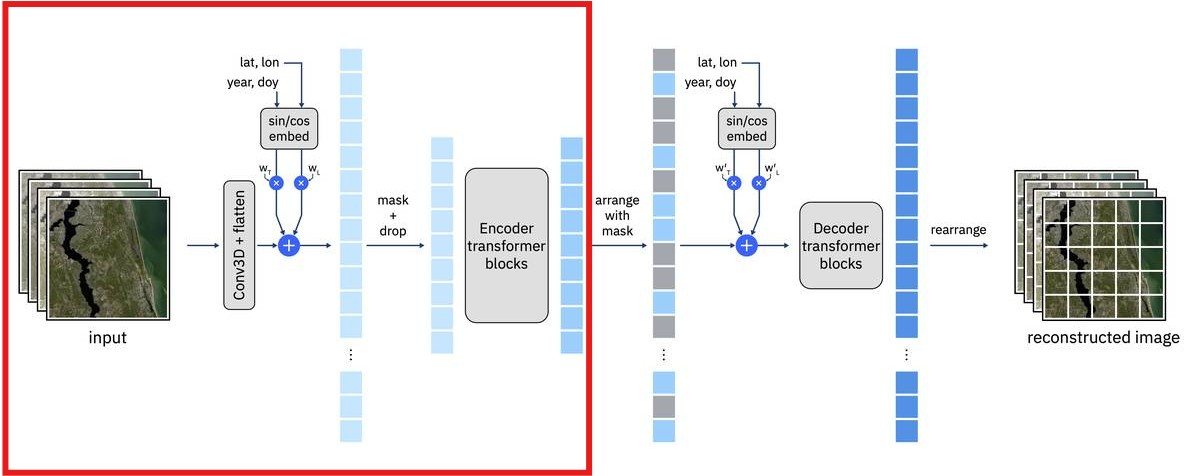

**How we reuse the pretrained foundation model for GPP prediction?**

For our GPP task, we keep: the patch embedding layers, the spatial-temporal embeddings, and the transformer encoder. Together, these form the Prithvi encoder. We remove the reconstruction decoder, since we are no longer reconstructing images.

To adapt the model for GPP prediction, we:
- Add a second branch to process 10 MERRA atmospheric variables. This creates a learned representation of meteorological conditions.
- Concatenate satellite features (from Prithvi encoder) and atmospheric features (from MERRA branch) to integrate the remote sensing and meteorology information.
- Add a regression head to pass the fused features into a linear layer and predict a single scalar value (GPP) for each site.



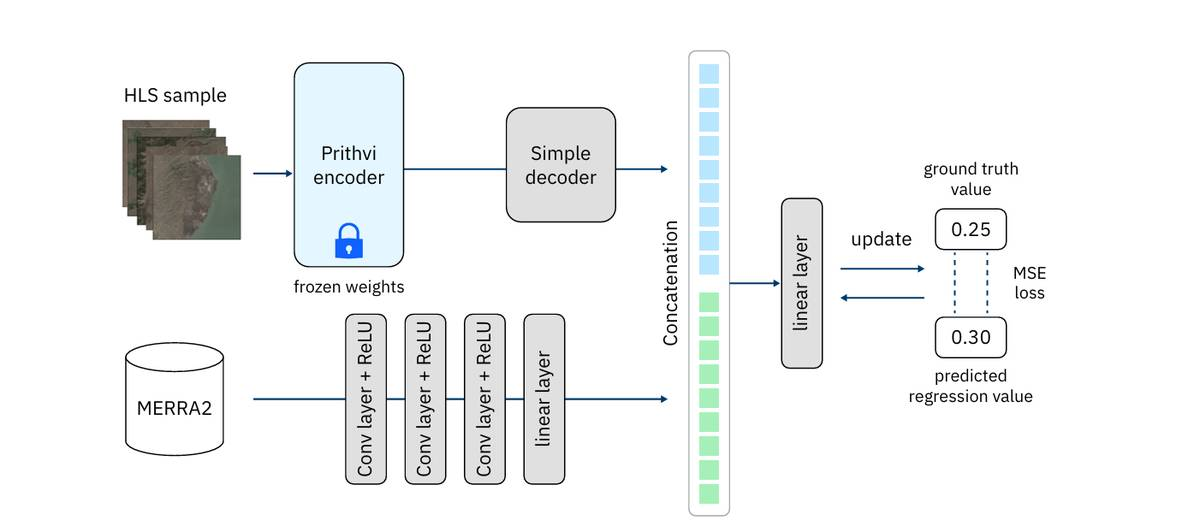

**300M-TL vs. 600M-TL**
- “300M” and “600M” refers to model size (number of parameters).
  - 300M-TL → ~300 million parameters
  - 600M-TL → ~600 million parameters
  - So the 600M model is roughly twice as large.
  - That usually means: Larger embedding dimension, more transformer blocks, more attention heads, larger MLP layers
- TL = Temporal and Location Information

## 6.1 Functions for Prithvi models

In [ ]:
class SimpleDecoder_comb_v2(nn.Module):
    def __init__(self, input_dim=1024, hidden_dim=256, output_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.LazyLinear(output_dim)  # <- avoids assuming token count
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))          # (B, seq, hidden)
        x = x.reshape(x.shape[0], -1)       # (B, seq*hidden)
        x = self.fc2(x)                     # (B, output_dim)
        return x

# Define the convolutional layers for the point1d MERRA input
class Pt1dConvBranch(nn.Module):
    def __init__(self):
        super(Pt1dConvBranch, self).__init__()
        self.conv1 = nn.Conv2d(10, 32, kernel_size=1)
        #self.bn1 = nn.BatchNorm2d(32)
        #self.drp = nn.Dropout(p=drp_rate)
        self.conv2 = nn.Conv2d(32, 16, kernel_size=1)
        #self.bn2 = nn.BatchNorm2d(16)
        #self.drp = nn.Dropout(p=drp_rate)
        self.conv3 = nn.Conv2d(16, 8, kernel_size=1)
        self.fc = nn.Linear(8, 64)  # Final output matches decoder output

    def forward(self, x):
        x = torch.relu(self.conv1(x)) #ORIGINAL merra [batch_size, 10, 1, 1] to [batch_size, 32, 1, 1]
        x = torch.relu(self.conv2(x))## Output shape [batch_size, 16, 1, 1]
        x = torch.relu(self.conv3(x))#Output shape [batch_size, 8, 1, 1]
        x=torch.reshape(x, (x.shape[0], x.shape[1]))#output reshape [batch_size, 8]
        x = self.fc(x) # Output shape [batch_size, 64]
        return x

class RegressionModel_flux(LightningModule):
    def __init__(self, prithvi_model, prithvi_embed_dim=None):
        super().__init__()
        self.prithvi_model = prithvi_model

        # Auto-detect embed dim if not provided
        if prithvi_embed_dim is None:
            prithvi_embed_dim = getattr(prithvi_model, "embed_dim", None)
            if prithvi_embed_dim is None and hasattr(prithvi_model, "prithvi_model"):
                prithvi_embed_dim = getattr(prithvi_model.prithvi_model, "embed_dim", None)
            if prithvi_embed_dim is None:
                raise ValueError("Cannot infer prithvi_embed_dim. Please pass 1024 (300M) or 1280 (600M).")

        print(f"[RegressionModel_flux] Using prithvi_embed_dim = {prithvi_embed_dim}")

        self.decoder = SimpleDecoder_comb_v2(input_dim=prithvi_embed_dim, hidden_dim=256, output_dim=64)
        self.pt1d_conv_branch = Pt1dConvBranch()
        self.fc_final = nn.Linear(128, 1)

    def forward(self, im2d, pt1d, **kwargs):
        # IMPORTANT: 4th arg is mask_ratio (float). Use 0.0 for regression/inference.
        pri_enc = self.prithvi_model(im2d, None, None, 0.0)
        dec_out = self.decoder(pri_enc)
        pt1d_out = self.pt1d_conv_branch(pt1d)
        combined = torch.cat((dec_out, pt1d_out), dim=1)
        output1 = self.fc_final(combined)
        return ModelOutput(output=output1)

class prithvi_terratorch(nn.Module):
    def __init__(self, prithvi_weight, model_instance, input_size):
        super(prithvi_terratorch, self).__init__()
        # load checkpoint for Prithvi_global
        self.weights_path = prithvi_weight
        self.checkpoint = torch.load(self.weights_path)
        self.input_size = input_size
        self.prithvi_model = model_instance
        self.prithvi_model.load_state_dict(self.checkpoint, strict=False)

    def freeze_encoder(self):
        freeze_module(self.prithvi_model)

    def forward(self,x,temp,loc,mask):
        latent,_,ids_restore = self.prithvi_model.forward(x,temp,loc,mask)
        return latent

In [ ]:
def get_mse(pred, targ):
    criterion = nn.MSELoss()
    mse_loss = criterion(pred, targ)
    return mse_loss.item()

def get_mae(pred, targ):
    criterion = nn.L1Loss()
    mae_loss = criterion(pred, targ)
    return mae_loss.item()

#can use sklearn R2 instead -- as used to evalute whole dataset
def get_r_sq(pred,targ):
    metric = R2Score()
    metric.update(pred, targ)
    r2=metric.compute()
    # Extracting the first element if it's a tensor with multiple elements
    if isinstance(r2, torch.Tensor) and r2.numel() > 1:
        return r2[0].item()
    else:
        return r2.item()

In [ ]:
import torch

@torch.no_grad()
def predict_zeroshot_stream(task, loader, device, use_amp=False):
    task.eval()
    task.to(device)

    preds = []
    targs = []

    for batch in loader:
        # Your dataset returns dicts like {"image","pt1d","mask"}
        x_img = batch["image"].to(device, non_blocking=True)
        x_pt  = batch["pt1d"].to(device, non_blocking=True)
        y     = batch["mask"].to(device, non_blocking=True)

        if use_amp and device.type == "cuda":
            with torch.cuda.amp.autocast(dtype=torch.float16):
                out = task.model(x_img, x_pt).output  # (B,1)
        else:
            out = task.model(x_img, x_pt).output

        preds.append(out.detach().float().cpu())
        targs.append(y.detach().float().cpu())

    pred = torch.cat(preds, dim=0).numpy()
    targ = torch.cat(targs, dim=0).numpy()
    return pred, targ

## 6.2 Prithvi-EO-2.0-300M-TL Earth Observation Foundation Model

### 6.2.1 Download checkpoint of the **300M-TL** foundation model from HuggingFace

**⚠️ Important**
- If you downloaded data and models to your own **Google Drive**, run **both cells** in this section.
- If you are using data and models from the **Shared Drive**, run **only the second cell**.


---



***Skip this cell** if you are using data from the **Shared Drive**.*

In [ ]:
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH_300M = os.path.join(MODEL_DIR, "Prithvi_EO_V2_300M_TL.pt")

from huggingface_hub import hf_hub_download, snapshot_download

if not os.path.isfile(MODEL_PATH_300M):
    hf_hub_download(
                  repo_id="ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL",
                  filename="Prithvi_EO_V2_300M_TL.pt",
                  local_dir= MODEL_DIR,
         )

***Start here** if you are using data from the Shared Drive.*

In [ ]:
from terratorch.models.backbones.prithvi_mae import PrithviViT

MODEL_PATH_300M = os.path.join(MODEL_DIR, "Prithvi_EO_V2_300M_TL.pt")
prithvi_instance_300M = PrithviViT(
        patch_size=patch_size_300M,
        num_frames=n_frame,
        in_chans=n_channel_300M,
        embed_dim=embed_dim_300M,
        decoder_depth=decoder_depth_300M,
        num_heads=num_heads_300M,
        mlp_ratio=mlp_ratio_300M,
        head_dropout=head_dropout_300M,
        backbone_input_size=[1,50,50],
        encoder_only=False,
        padding=True,
)
prithvi_model_300M = prithvi_terratorch(MODEL_PATH_300M, prithvi_instance_300M, [1, 50, 50])
prithvi_model_300M.freeze_encoder()

# Instantiate the regression model
model_comb_300M = RegressionModel_flux(prithvi_model_300M, prithvi_embed_dim = embed_dim_300M)

criterion_300M = nn.MSELoss()
optimizer_300M = optim.AdamW(model_comb_300M.parameters(), lr=learning_rate_300M, weight_decay=0.05)
scheduler_300M = ReduceLROnPlateau(optimizer_300M, mode='min', factor=0.9, patience=5)

task_300M = PixelwiseRegressionTask(None, None, model=model_comb_300M, loss="mse", optimizer="AdamW")

### 6.2.2 (DO NOT RUN) **Fine-tune** the **300M-TL** foundation model
- Only run the model finetuning with high-ram GPU

In [ ]:
class NoPlotDataset:
    """Adapter that provides .plot() expected by TerraTorch."""
    def __init__(self, base_ds):
        self.base_ds = base_ds

    def plot(self, sample):
        return None  # disable plotting in tutorial

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        return self.base_ds[idx]

import lightning as L

class FrozenDataModule(L.LightningDataModule):
    def __init__(self, train_loader, val_loader):
        super().__init__()
        self._train_loader = train_loader
        self._val_loader = val_loader

        # Provide val_dataset with a .plot() method
        base_val_ds = getattr(val_loader, "dataset", None)
        self.val_dataset = NoPlotDataset(base_val_ds) if base_val_ds is not None else None

    def train_dataloader(self):
        return self._train_loader

    def val_dataloader(self):
        return self._val_loader


In [ ]:
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import RichProgressBar
import torch

trainer = Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    max_epochs=n_iteration,
    precision="16-mixed" if torch.cuda.is_available() else 32,
    num_sanity_val_steps=0,   # IMPORTANT: avoids extra memory use
    log_every_n_steps=20,
    enable_checkpointing=False,   # you are saving manually
)

dm = FrozenDataModule(train_loader, test_loader)

# train (no datamodule)
trainer.fit(model=task, datamodule=dm)
# save weights
torch.save(task.model.state_dict(),
           TRAINED_MODEL_PATH_300M)
print("Saved weights")


### 6.2.3 Load **fine-tuned 300M-TL** foundation model

In [ ]:
# -----------------------------
# 1) Load weights (saved from task.model.state_dict())
# -----------------------------

state = torch.load(TRAINED_MODEL_PATH_300M, map_location="cpu")
task_300M.model.load_state_dict(state, strict=True)   # <-- load into task.model
task_300M.to(device).eval()
print("Loaded weights:", TRAINED_MODEL_PATH_300M)

### 6.2.4 Predict GPP with fine-tuned Prithvi-EO-2.0-300M-TL

In [ ]:
# -----------------------------
# 2) Predict WITHOUT trainer.predict (stable in Colab/local)
#    Use the SAME loaders already created (frozen)
# -----------------------------
import numpy as np
import torch

@torch.no_grad()
def predict_on_loader(task, loader, device):
    task.eval()
    preds, targs = [], []

    for batch in loader:
        x_img = batch["image"].to(device, non_blocking=True)
        x_pt  = batch["pt1d"].to(device, non_blocking=True)
        y     = batch["mask"].to(device, non_blocking=True)

        out = task.model(x_img, x_pt)
        if hasattr(out, "output"):   # if model returns an object with .output
            out = out.output

        preds.append(out.detach().float().cpu().numpy())
        targs.append(y.detach().float().cpu().numpy())

    pred = np.concatenate(preds, axis=0)
    targ = np.concatenate(targs, axis=0)

    # enforce (N,1)
    if pred.ndim == 1: pred = pred[:, None]
    if targ.ndim == 1: targ = targ[:, None]
    return pred, targ



In [ ]:
# test split
pred_test, targ_test = predict_on_loader(task_300M, test_loader, device)

# train split (for eval only)
pred_train, targ_train = predict_on_loader(task_300M, train_loader, device)

print("pred_test / targ_test:", pred_test.shape, targ_test.shape)
print("pred_train / targ_train:", pred_train.shape, targ_train.shape)

In [ ]:
pred_test = _to_col(pred_test)
targ_test = _to_col(targ_test)

pred_train = _to_col(pred_train)
targ_train = _to_col(targ_train)

# --- R2 on normalized scale (optional) ---
r2_300M_train = r2_score(targ_train.reshape(-1), pred_train.reshape(-1))
r2_300M_test  = r2_score(targ_test.reshape(-1),  pred_test.reshape(-1))

print("R2 train (normalized):", r2_score(targ_train.reshape(-1), pred_train.reshape(-1)))
print("R2 test  (normalized):", r2_score(targ_test.reshape(-1),  pred_test.reshape(-1)))

# --- Unnormalize ---
pred_train_u = unnormalize(pred_train, gpp_means, gpp_stds)
targ_train_u = unnormalize(targ_train, gpp_means, gpp_stds)
pred_test_u  = unnormalize(pred_test,  gpp_means, gpp_stds)
targ_test_u  = unnormalize(targ_test,  gpp_means, gpp_stds)

# --- (Optional) Save per-sample CSV for TEST ---
os.makedirs(metrics_dir, exist_ok=True)

pred_flat = pred_test_u.reshape(-1, 1)
targ_flat = targ_test_u.reshape(-1, 1)

mse_unnorm = (targ_flat - pred_flat) ** 2
mae_unnorm = np.abs(targ_flat - pred_flat)
rel_err_unnorm = np.abs(targ_flat - pred_flat) / (np.abs(targ_flat) + 1e-8)

test_stack = np.hstack([
    pred_test,            # pred_norm
    targ_test,            # targ_norm
    pred_flat,            # pred_unnorm
    targ_flat,            # targ_unnorm
    mse_unnorm,
    mae_unnorm,
    rel_err_unnorm
])

out_csv = os.path.join(
    metrics_dir,
    f"Prithvi300M-TL_test_eval_MSELoss_ep{n_iteration}_lr{learning_rate_300M}_{optim_name}_sc{sch}_yr{year_to_test}.csv"
)

np.savetxt(
    out_csv,
    test_stack,
    fmt="%.6f",
    delimiter=",",
    newline="\n",
    header="pred_n,tar_n,pred,tar,mse,mae,rel_err",
    comments=""
)
print("Saved:", out_csv)

# --- Make the 2-panel figure ---
out_png = os.path.join(plots_dir, f"Prithvi300M-TL_full_obs_vs_pred_yr{year_to_test}.png")

make_obs_vs_pred_2panel(
    targ_train=targ_train_u, pred_train=pred_train_u,
    targ_test=targ_test_u,   pred_test=pred_test_u,
    title="Prithvi-EO-2.0-300M-TL",
    test_year=year_to_test,
    units="($g \; C \; m^{-2} \; day^{-1}$)",      # edit if needed
    out_png=out_png,
    point_size=45,
    alpha=0.35
)

## 6.3 Prithvi-EO-2.0-600M-TL Earth Observation Foundation Model

**Important Note on RAM Usage**

Loading the pre-fine-tuned Prithvi-EO-2.0-600M-TL model requires a large amount of memory.
If you are not using a High-RAM runtime (e.g., Colab Pro/Pro+ with High-RAM enabled), the session may crash due to memory limits.

To ensure the tutorial runs smoothly for everyone, we load the pre-generated predictions from our own pre-fine-tuned model instead of loading the full 600M-TL model during the live session.

If you would like to:

- Fine-tune the 600M-TL model yourself, you can modify the code in Section 5.2 after the tutorial session.

- Or directly access our pre-fine-tuned model from Hugging Face and run it on your own High-RAM setup.

### 6.3.1 Predict GPP with fine-tuned Prithvi-EO-2.0-600M-TL model

In [ ]:
import numpy as np
from sklearn.metrics import r2_score

data = np.load(PREDICTION_PATH_600M)

pred_test  = data["pred_test"]
targ_test  = data["targ_test"]
pred_train = data["pred_train"]
targ_train = data["targ_train"]

In [ ]:
pred_test = _to_col(pred_test)
targ_test = _to_col(targ_test)

pred_train = _to_col(pred_train)
targ_train = _to_col(targ_train)

# --- R2 on normalized scale (optional) ---
r2_600M_train = r2_score(targ_train.reshape(-1), pred_train.reshape(-1))
r2_600M_test  = r2_score(targ_test.reshape(-1),  pred_test.reshape(-1))
print("R2 train (normalized):", r2_score(targ_train.reshape(-1), pred_train.reshape(-1)))
print("R2 test  (normalized):", r2_score(targ_test.reshape(-1),  pred_test.reshape(-1)))

# --- Unnormalize ---
pred_train_u = unnormalize(pred_train, gpp_means, gpp_stds)
targ_train_u = unnormalize(targ_train, gpp_means, gpp_stds)
pred_test_u  = unnormalize(pred_test,  gpp_means, gpp_stds)
targ_test_u  = unnormalize(targ_test,  gpp_means, gpp_stds)

# --- (Optional) Save per-sample CSV for TEST like you already do ---
os.makedirs(metrics_dir, exist_ok=True)

pred_flat = pred_test_u.reshape(-1, 1)
targ_flat = targ_test_u.reshape(-1, 1)

mse_unnorm = (targ_flat - pred_flat) ** 2
mae_unnorm = np.abs(targ_flat - pred_flat)
rel_err_unnorm = np.abs(targ_flat - pred_flat) / (np.abs(targ_flat) + 1e-8)

test_stack = np.hstack([
    pred_test,            # pred_norm
    targ_test,            # targ_norm
    pred_flat,            # pred_unnorm
    targ_flat,            # targ_unnorm
    mse_unnorm,
    mae_unnorm,
    rel_err_unnorm
])

out_csv = os.path.join(
    metrics_dir,
    f"Prithvi600M-TL_test_eval_MSELoss_ep{n_iteration}_lr{learning_rate_600M}_{optim_name}_sc{sch}_yr{year_to_test}.csv"
)

np.savetxt(
    out_csv,
    test_stack,
    fmt="%.6f",
    delimiter=",",
    newline="\n",
    header="pred_n,tar_n,pred,tar,mse,mae,rel_err",
    comments=""
)
print("Saved:", out_csv)

# --- Make the 2-panel figure (like your screenshot) ---
out_png = os.path.join(plots_dir, f"Prithvi600M-TL_full_obs_vs_pred_yr{year_to_test}.png")

make_obs_vs_pred_2panel(
    targ_train=targ_train_u, pred_train=pred_train_u,
    targ_test=targ_test_u,   pred_test=pred_test_u,
    title="Prithvi-EO-2.0-600M-TL",
    test_year=year_to_test,
    units="($g \; C \; m^{-2} \; day^{-1}$)",      # edit if needed
    out_png=out_png,
    point_size=45,
    alpha=0.35
)


# 7 Other Baseline models

## 7.1 Data conversion for Random Forest and XGBoost
- Convert train and test loaders to arrays for Random Forest and XGBoost

In [ ]:
import numpy as np
import torch

@torch.no_grad()
def materialize_frozen_loader(loader, device="cpu", max_batches=None):
    """
    Assumes each batch is a dict with keys:
      batch["image"] : (B, C, T, H, W) float tensor
      batch["pt1d"]  : (B, 10, 1, 1) or (B, 10) float tensor
      batch["mask"]  : (B, 1) or (B,) float tensor (target, usually normalized)

    Returns:
      X_img  : (N, C, T, H, W) float32  (still useful for ResNet/torch)
      X_merra: (N, 10) float32
      y      : (N, 1) float32
    """
    X_img_list, X_m_list, y_list = [], [], []

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        x_img = batch["image"]
        x_m   = batch["pt1d"]
        y     = batch["mask"]

        # (B,10,1,1) -> (B,10)
        if x_m.ndim == 4:
            x_m = x_m.squeeze(-1).squeeze(-1)
        if y.ndim == 1:
            y = y[:, None]

        # move to cpu for numpy
        X_img_list.append(x_img.detach().cpu())
        X_m_list.append(x_m.detach().cpu())
        y_list.append(y.detach().cpu())

    X_img  = torch.cat(X_img_list, dim=0).numpy().astype(np.float32)
    X_merra = torch.cat(X_m_list, dim=0).numpy().astype(np.float32)
    y      = torch.cat(y_list, dim=0).numpy().astype(np.float32)
    return X_img, X_merra, y



In [ ]:
# Materialize train/test once (fast enough for 37 sites; you can cap max_batches for demo)
Ximg_tr, Xmerra_tr, y_tr = materialize_frozen_loader(train_loader)
Ximg_te, Xmerra_te, y_te = materialize_frozen_loader(test_loader)

print("Train:", Ximg_tr.shape, Xmerra_tr.shape, y_tr.shape)
print("Test :", Ximg_te.shape, Xmerra_te.shape, y_te.shape)

# Ximg: (N, C, T, H, W) -> per-band mean over T,H,W => (N, C)
img_feat_tr = Ximg_tr.mean(axis=(2,3,4))
img_feat_te = Ximg_te.mean(axis=(2,3,4))

X_tab_tr = np.concatenate([img_feat_tr, Xmerra_tr], axis=1)   # (N, C+10)
X_tab_te = np.concatenate([img_feat_te, Xmerra_te], axis=1)

print("Tabular X:", X_tab_tr.shape, X_tab_te.shape)

## 7.2 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import os
import numpy as np

# ---- train RF ----
rf = RandomForestRegressor(
    n_estimators=400,
    random_state=0,
    n_jobs=-1
)
rf.fit(X_tab_tr, y_tr.ravel())

# ---- predict ----
pred_tr = rf.predict(X_tab_tr)[:, None]
pred_te = rf.predict(X_tab_te)[:, None]

r2_rf_train = r2_score(y_tr.reshape(-1), pred_tr.reshape(-1))
r2_rf_test  = r2_score(y_te.reshape(-1), pred_te.reshape(-1))
print("RF R2 train (normalized):", r2_score(y_tr.reshape(-1), pred_tr.reshape(-1)))
print("RF R2 test  (normalized):", r2_score(y_te.reshape(-1), pred_te.reshape(-1)))

# ---- unnormalize (to physical units) ----
pred_tr_u = unnormalize(pred_tr, gpp_means, gpp_stds)
y_tr_u    = unnormalize(y_tr,   gpp_means, gpp_stds)
pred_te_u = unnormalize(pred_te, gpp_means, gpp_stds)
y_te_u    = unnormalize(y_te,    gpp_means, gpp_stds)

# ---- make consistent figure ----
os.makedirs(plots_dir, exist_ok=True)
out_png = os.path.join(plots_dir, f"RF_obs_vs_pred_yr{year_to_test}.png")

make_obs_vs_pred_2panel(
    targ_train=y_tr_u, pred_train=pred_tr_u,
    targ_test=y_te_u,  pred_test=pred_te_u,
    title="Random Forest",
    test_year=year_to_test,
    units="($g \; C \; m^{-2} \; day^{-1}$)",
    out_png=out_png,
    point_size=45,
    alpha=0.35
)

# --- (Optional) Save metrics for Random Forest ---
os.makedirs(metrics_dir, exist_ok=True)

# -----------------------------
# 1) Flatten arrays (normalized + unnormalized)
# -----------------------------
pred_norm_flat = pred_te.reshape(-1, 1)
targ_norm_flat = y_te.reshape(-1, 1)

pred_unnorm_flat = pred_te_u.reshape(-1, 1)
targ_unnorm_flat = y_te_u.reshape(-1, 1)

# -----------------------------
# 2) Per-sample metrics (unnormalized)
# -----------------------------
mse_unnorm = (targ_unnorm_flat - pred_unnorm_flat) ** 2
mae_unnorm = np.abs(targ_unnorm_flat - pred_unnorm_flat)
rel_err_unnorm = np.abs(targ_unnorm_flat - pred_unnorm_flat) / (np.abs(targ_unnorm_flat) + 1e-8)

test_stack = np.hstack([
    pred_norm_flat,
    targ_norm_flat,
    pred_unnorm_flat,
    targ_unnorm_flat,
    mse_unnorm,
    mae_unnorm,
    rel_err_unnorm
])

# -----------------------------
# 3) Save per-sample CSV
# -----------------------------
out_csv = os.path.join(
    metrics_dir,
    f"RF_test_eval_yr{year_to_test}.csv"
)

np.savetxt(
    out_csv,
    test_stack,
    fmt="%.6f",
    delimiter=",",
    newline="\n",
    header="pred_norm,targ_norm,pred_unnorm,targ_unnorm,mse,mae,rel_err",
    comments=""
)

print("Saved per-sample metrics to:", out_csv)

# # -----------------------------
# # 4) Save summary metrics
# # -----------------------------
# import json

# rf_metrics_summary = {
#     "model": "Random Forest",
#     "test_year": int(year_to_test),
#     "r2_train_norm": float(r2_rf_train),
#     "r2_test_norm": float(r2_rf_test),
#     "mae_test_unnorm_mean": float(mae_unnorm.mean()),
#     "mse_test_unnorm_mean": float(mse_unnorm.mean())
# }

# summary_path = os.path.join(
#     metrics_dir,
#     f"RF_summary_metrics_yr{year_to_test}.json"
# )

# with open(summary_path, "w") as f:
#     json.dump(rf_metrics_summary, f, indent=4)

# print("Saved summary metrics to:", summary_path)

## 7.3 XGBoost

In [ ]:
# !pip -q install xgboost
import os
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# -------------------------
# 1) Train XGBoost (on normalized targets)
# -------------------------
xgb = XGBRegressor(
    n_estimators=2000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=0,
    tree_method="hist",      # change to "gpu_hist" if you want GPU + have it available
    n_jobs=-1
)

xgb.fit(X_tab_tr, y_tr.ravel())

# -------------------------
# 2) Predict (normalized)
# -------------------------
pred_tr = xgb.predict(X_tab_tr)[:, None]
pred_te = xgb.predict(X_tab_te)[:, None]

r2_xgb_train = r2_score(y_tr.reshape(-1), pred_tr.reshape(-1))
r2_xgb_test = r2_score(y_te.reshape(-1), pred_te.reshape(-1))
print("XGB R2 train (normalized):", r2_score(y_tr.reshape(-1), pred_tr.reshape(-1)))
print("XGB R2 test  (normalized):", r2_score(y_te.reshape(-1), pred_te.reshape(-1)))

# -------------------------
# 3) Unnormalize for plotting (physical units)
# -------------------------
pred_tr_u = unnormalize(pred_tr, gpp_means, gpp_stds)
y_tr_u    = unnormalize(y_tr,   gpp_means, gpp_stds)
pred_te_u = unnormalize(pred_te, gpp_means, gpp_stds)
y_te_u    = unnormalize(y_te,    gpp_means, gpp_stds)

# -------------------------
# 4) Plot with your consistent figure function
# -------------------------
os.makedirs(plots_dir, exist_ok=True)
out_png = os.path.join(plots_dir, f"XGB_obs_vs_pred_yr{year_to_test}.png")

make_obs_vs_pred_2panel(
    targ_train=y_tr_u, pred_train=pred_tr_u,
    targ_test=y_te_u,  pred_test=pred_te_u,
    title="XGBoost",
    test_year=year_to_test,
    units="($g \; C \; m^{-2} \; day^{-1}$)",
    out_png=out_png,
    point_size=45,
    alpha=0.35
)

print("Saved figure:", out_png)


os.makedirs(metrics_dir, exist_ok=True)

# -----------------------------
# 1) Flatten arrays (normalized + unnormalized)
# -----------------------------
pred_norm_flat = pred_te.reshape(-1, 1)
targ_norm_flat = y_te.reshape(-1, 1)

pred_unnorm_flat = pred_te_u.reshape(-1, 1)
targ_unnorm_flat = y_te_u.reshape(-1, 1)

# -----------------------------
# 2) Per-sample metrics (unnormalized)
# -----------------------------
mse_unnorm = (targ_unnorm_flat - pred_unnorm_flat) ** 2
mae_unnorm = np.abs(targ_unnorm_flat - pred_unnorm_flat)
rel_err_unnorm = np.abs(targ_unnorm_flat - pred_unnorm_flat) / (np.abs(targ_unnorm_flat) + 1e-8)

test_stack = np.hstack([
    pred_norm_flat,
    targ_norm_flat,
    pred_unnorm_flat,
    targ_unnorm_flat,
    mse_unnorm,
    mae_unnorm,
    rel_err_unnorm
])

# -----------------------------
# 3) Save per-sample CSV
# -----------------------------
out_csv = os.path.join(
    metrics_dir,
    f"XGB_test_eval_yr{year_to_test}.csv"
)

np.savetxt(
    out_csv,
    test_stack,
    fmt="%.6f",
    delimiter=",",
    newline="\n",
    header="pred_norm,targ_norm,pred_unnorm,targ_unnorm,mse,mae,rel_err",
    comments=""
)

print("Saved per-sample metrics to:", out_csv)

# # -----------------------------
# # 4) Save summary metrics (JSON)
# # -----------------------------
# xgb_metrics_summary = {
#     "model": "XGBoost",
#     "test_year": int(year_to_test),
#     "r2_train_norm": float(r2_xgb_train),
#     "r2_test_norm": float(r2_xgb_test),
#     "mae_test_unnorm_mean": float(mae_unnorm.mean()),
#     "mse_test_unnorm_mean": float(mse_unnorm.mean()),
# }

# summary_path = os.path.join(
#     metrics_dir,
#     f"XGB_summary_metrics_yr{year_to_test}.json"
# )

# with open(summary_path, "w") as f:
#     json.dump(xgb_metrics_summary, f, indent=4)

# print("Saved summary metrics to:", summary_path)


# 8 Model Comparison

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Manually specify order
# -----------------------------
model_order = [
    "Prithvi-EO-2.0-600M-TL",
    "Prithvi-EO-2.0-300M-TL",
    "XGBoost",
    "Random Forest",
]

r2_by_model = {
    "Prithvi-EO-2.0-300M-TL": r2_300M_test,
    "Prithvi-EO-2.0-600M-TL": r2_600M_test,
    "Random Forest": r2_rf_test,
    "XGBoost": r2_xgb_test,
}

names = model_order
vals = np.array([r2_by_model[k] for k in names], dtype=float)

# -----------------------------
# 2) Make square figure
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6))   # square

bars = ax.bar(names, vals)

# -----------------------------
# 3) Font size control
# -----------------------------
label_fontsize = 14
tick_fontsize  = 12
title_fontsize = 16
value_fontsize = 12

# -----------------------------
# 3) Labels and Title
# -----------------------------
ax.set_ylabel("R² (Test)", fontsize=label_fontsize)

# Move x-axis label closer using labelpad
ax.set_xlabel("Model", fontsize=label_fontsize, labelpad=4)

ax.set_title("Model Performance Comparison", fontsize=title_fontsize)

ax.set_ylim(0, max(0.0, float(vals.max())) * 1.15)
# Set clean y-axis scale
yticks = [0.2, 0.4, 0.6, 0.8]
ax.set_yticks(yticks)
ax.grid(axis="y", linestyle="--", alpha=0.4)


# Grid
ax.grid(axis="y", linestyle="--", alpha=0.4)


# -----------------------------
# Rotate model names more
# -----------------------------
ax.tick_params(axis="x", rotation=60, labelsize=tick_fontsize)
ax.tick_params(axis="y", labelsize=tick_fontsize)

# Improve rotated label alignment
for tick in ax.get_xticklabels():
    tick.set_horizontalalignment("right")

# =============================
# Save figure
# =============================
save_path = os.path.join(plots_dir, "model_performance_comparison.png")
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")

print(f"Figure saved to: {save_path}")

plt.show()